In [ ]:
import pandas as pd

url = 'https://www.capitalfund.com.tw/etf/product/detail/378/interest'
dfs = pd.read_html()
# 印出表格數量
print(len(dfs))




In [3]:
import requests
def get00937bdivdata():
    url = 'https://www.capitalfund.com.tw/etf/product/detail/378/interest'
    response = requests.get(url)
    if response.status_code == 200:
        html_content = response.text
    else:
        print('Failed to retrieve the webpage. Status code:', response.status_code)


    from bs4 import BeautifulSoup
    import pandas as pd


    # 使用BeautifulSoup解析HTML
    soup = BeautifulSoup(html_content, 'html.parser')

    # 找到表格的所有行
    rows = soup.find_all('div', class_='tr')

    data = []
    for row in rows:
        # 找到每行的所有列
        cols = row.find_all('div', class_='td')
        cols = [col.text for col in cols]
        for i in range(0,len(cols)):
            cols[i] = cols[i].replace('配息基準日','').replace('除息交易日','').replace('配息發放日','').replace('每單位分配金額(元)','').replace('除息日前一日之淨值','').replace('年化配息率	','').replace('配息頻率','')
            
        data.append(cols)

    # 將資料轉換為data frame
    df = pd.DataFrame(data, columns=['配息基準日', '除息交易日', '配息發放日', '每單位分配金額(元)', '除息日前一日之淨值', '年化配息率', '配息頻率'])

    #print(df)
    df.dropna(axis=0,inplace=True)
    df['除息交易日'] = pd.to_datetime(df['除息交易日'], format='%Y/%m/%d', errors='coerce')

    return df


df1 = get00937bdivdata()
df1 = df1.set_index('除息交易日',drop=True)
df1

In [ ]:
import requests
import json

# 設定群益投信 ETF 代號
etf_id = "00919"

# 發送 HTTP 請求
response = requests.get(f"https://www.capitalfund.com.tw/etf/product/detail/{etf_id}/interest")

# 解析 HTML 回應
soup = BeautifulSoup(response.content, "html.parser")

# 尋找配息資料表格
table = soup.find("table", class_="table-bordered")

# 輸出配息資料
for row in table.find_all("tr"):
    cells = row.find_all("td")
    print(f"配息基準日：{cells[0].text}")
    print(f"除息交易日：{cells[1].text}")
    print(f"配息發放日：{cells[2].text}")
    print(f"每單位分配金額：{cells[3].text}")
    print(f"除息日前一日之淨值：{cells[4].text}")
    print(f"年化配息率：{cells[5].text}")
    print()


In [ ]:
import yfinance as yf
import json
import pandas as pd
import logging
import subprocess    
dividends = yf.Ticker('00751B.TWO').dividends
df = pd.Series(dividends)
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'].dt.strftime('%Y/%m/%d'))
#df = df.set_index('Date',drop=True)
df


In [51]:
s = df.tail(1)
s = s.reset_index()
s['Date'][0].year 
s

,index,Date,Dividends
0,19,2024-03-18,0.44


In [19]:
s = pd.to_datetime(dividends.tail(1).index[0].strftime('%Y/%m/%d'))
#s = pd.to_datetime(dividends.index[0].strftime('%Y/%m/%d'))

In [19]:
import pandas as pd
dd = pd.read_html('https://www.moneydj.com/ETF/X/Basic/Basic0005.xdjhtm?etfid=00751B.TW')
dd[1]

,配息基準日,除息日,發放日,幣別,短期資本利得,長期資本利得,配息總額
0,2024/03/15,2024/03/18,2024/04/15,台幣,NaN,NaN,0.440
1,2023/12/24,2023/12/18,2024/01/12,台幣,NaN,NaN,0.450
2,2023/09/24,2023/09/18,2023/10/17,台幣,NaN,NaN,0.450
3,2023/06/24,2023/06/16,2023/07/14,台幣,NaN,NaN,0.440
4,2023/03/22,2023/03/16,2023/04/14,台幣,NaN,NaN,0.450
5,2022/12/24,2022/12/16,2023/01/13,台幣,NaN,NaN,0.460
6,2022/09/26,2022/09/20,2022/10/17,台幣,NaN,NaN,0.440
7,2022/06/25,2022/06/17,2022/07/14,台幣,NaN,NaN,0.420
8,2022/03/22,2022/03/16,2022/04/13,台幣,NaN,NaN,0.370
9,2021/12/22,2021/12/16,2022/01/12,台幣,NaN,NaN,0.350


In [23]:
df = dd[1]
df.rename(columns={'除息日': 'Date','配息總額':'Dividends'}, inplace=True)

type(df['Date'][0])

str

In [80]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = 'https://mis.twse.com.tw/stock/etf_nav.jsp?ex=tse'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')
encoding = response.encoding
print('網頁編碼方式:', encoding)


網頁編碼方式: UTF-8


讀取動態網頁 

In [33]:
from selenium import webdriver
def opendynamicWeb(url):
    # 创建 WebDriver 对象
    driver = webdriver.Edge()  # 使用Chrome浏览器，需要下载对应的 WebDriver，并确保路径正确

    
    driver.get(url)

    driver.implicitly_wait(20)  # 等待10秒，可根据实际情况调整

    dynamic_content = driver.page_source

    driver.quit()
    return dynamic_content
import pandas as pd
url = 'https://mis.twse.com.tw/stock/etf_nav.jsp?ex=tse'
dynamic_content = opendynamicWeb(url)
df = pd.read_html(dynamic_content)


In [ ]:

#soup = BeautifulSoup(dynamic_content, 'html.parser')
ddf = df[1]
ddf1 =ddf[ddf['ETF代號/名稱'].str.contains('0050|0056|00878|00929|00940|00930|00713')]
ddf1

In [71]:
tbody = soup.find('tbody')  # 找到<tbody>标签

tr_tags = tbody.find_all('tr')  # 找到所有<tr>标签
tr_tags

[]

In [21]:
div_container = soup.find('div', id='container')  # 找到id为'container'的<div>标签

table = div_container.find('table')  # 找到<div>中的表格\
df = pd.read_html(str(table))[0]  # 将表格数据转换为DataFrame


,0,1
0,基本市況報導網站 Market Information System,正體中文 English


In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
#url = 'https://www.yuantafunds.com/myfund/dividend/history?fundid=1181'
url = 'https://www.moneydj.com/ETF/X/Basic/Basic0005.xdjhtm?etfid=00751B.TW'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

text_content = response.content

#print(encoded_content)
#tbody = encoded_content.find('tbody')  # 找到<tbody>标签
table = soup.find('table')  # 找到网页中的表格数据

#df = pd.read_html(str(table))[0]  # 将表格数据转换为DataFrame
decoded_content = text_content.decode('utf-8')  # 解码为utf-8

#print(df)
decoded_content



'\r\n\r\n<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">\r\n\r\n\r\n\r\n<html xmlns="http://www.w3.org/1999/xhtml" >\r\n<meta HTTP-EQUIV="Content-Type" CONTENT="text/html; charset=UTF-8" />\r\n<meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1"/>\r\n<meta name="robots" content="index, follow" />\r\n<meta name="googlebot" content="index, follow" />\r\n<meta name="viewport" content="width=device-width" /> \r\n<meta property="og:image" content="https://www.moneydj.com/etf/images/FB-ETF.png" />\r\n<head><title>\r\n\t元大AAA至A公司債-00751B.TW-ETF配息狀況 - MoneyDJ理財網\r\n</title>\r\n\t<!--CSS -->\r\n\t<link href="/etf/js/etfstyle.css" rel="stylesheet" type="text/css" /><link href="/etf/css/extendETF.css" rel="stylesheet" type="text/css" /><link href="/etf/css/datalist.css" rel="stylesheet" type="text/css" />\r\n\t<script type="text/javascript" src="/funddjx/js/JQuery/jquery-3.6.0.min.js"></script>\r\n\t<script type="t

In [2]:
table

<table border="0" cellpadding="0" cellspacing="0" style="border-collapse: collapse" width="100%">
<tr><td>
<!--link-->
<div id="Logo">
<span class="date"> <!--<SCRIPT LANGUAGE='javascript'>getDDate();</SCRIPT>--> </span>
<span class="user"> <!--<a target='blank' href='https://secure.moneydj.com/e/newage/exa0100a.asp'>加入會員</a>--> </span>
<!--Logo-->
<div id="Link-MDJ1"><a href="/"><img alt="MoneyDJ理財網" border="0" height="43" src="/etf/images/spacer.gif" width="155"/></a></div>
<div id="Link-MDJ2"><a href="/"><img alt="MoneyDJ理財網" border="0" height="30" src="/etf/images/spacer.gif" width="70"/></a></div>
<div id="Link-FDJ"><a href="/etf/"><img alt="ETF基智網" border="0" height="30" src="/etf/images/spacer.gif" width="70"/></a></div>
</div>
</td>
<td>
<script async="" src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script>
<script>
			  window.googletag = window.googletag || {cmd: []};
			  googletag.cmd.push(function() {
			    googletag.defineSlot('/126805407/ETF_FixedBanner',

In [34]:
import pandas as pd
url = 'https://www.yuantafunds.com/myfund/dividend/history?fundid=1181'
dynamic_content = opendynamicWeb(url)
df = pd.read_html(dynamic_content)

'<html class="swal2-shown swal2-height-auto"><head><meta http-equiv="X-UA-Compatible" content="IE=edge">\n  <script type="text/javascript" async="" src="https://www.gstatic.com/recaptcha/releases/moV1mTgQ6S91nuTnmll4Y9yf/recaptcha__zh_tw.js" crossorigin="anonymous" integrity="sha384-O23GnCqU4PoBUGwi0mcWHYQW3ZWtVk4PVRxXo9NK/jegcPvA729vPk6TSVR37yCf"></script><script type="text/javascript" id="www-widgetapi-script" src="https://www.youtube.com/s/player/3b96d06c/www-widgetapi.vflset/www-widgetapi.js" async=""></script><script async="" src="https://d.line-scdn.net/n/line_tag/public/release/v1/lt.js"></script><script async="" src="https://d.line-scdn.net/n/line_tag/public/release/v1/lt.js"></script><script type="text/javascript" async="" src="https://www.google-analytics.com/analytics.js"></script><script type="text/javascript" async="" src="https://www.googletagmanager.com/gtag/js?id=G-YW1V0WSLFY&amp;l=dataLayer&amp;cx=c"></script><script async="" src="https://www.google-analytics.com/analy
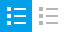
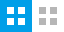
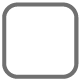
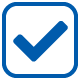
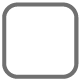
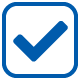
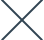
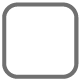
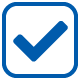
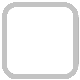
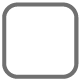
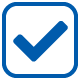

In [37]:
dynamic_content
